In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

Importing CSV Data as Panda Dataframe

In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

## Data checks to perform

1. Check Missing Values
2. Check Duplicates
3. Check Datatypes
4. Check the number of Unique values of each columns
5. Check Statistics of Dataset
6. Check various categories present in different Categorical columns

### Checking Missing Values

In [4]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There is no Missing values in Dataset  

### Check Duplicates

In [5]:
df.duplicated().sum()

0

#### There is no duplicate value in the dataset. Hence we can proceed with the analysis.

### Check Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Checking the Number of Unique Values in Each Column

In [7]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### Check Statistics of Data set

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight

* From above description of numerical data, all means are very close to each other - between 66 and 68.05;
* All standard deviations are also close - between 14.6 and 15.19;
* While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading much higher = 17

#### Exploring Data

In [9]:
print("Categories in 'gender' Variable: ",end=" ")
print(df['gender'].unique())

print("Categories in 'race ethnicity' Variable: ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' Variable: ",end=" ")
print(df['parental_level_of_education'].unique())   

print("Categories in 'lunch' Variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' Variable: ",end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' Variable:  ['female' 'male']
Categories in 'race ethnicity' Variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' Variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' Variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' Variable:  ['none' 'completed']


In [10]:
# Defining categorical & numerical columns

numeric_featrues = [feature for feature in df.columns if df[feature].dtype != 'O'] # O stands for object data type which is used for categorical features
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O'] # O stands for object data type which is used for categorical features

# Print Columns

print("We have {} Numerical Features : {}".format(len(numeric_featrues),numeric_featrues))
print("We have {} Categorical Features : {}".format(len(categorical_features),categorical_features))

We have 3 Numerical Features : ['math_score', 'reading_score', 'writing_score']
We have 5 Categorical Features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


#### Adding Columns for "Total Score" and "Average" 

In [11]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
math_full = df[df['math_score'] == 100]['average_score'].count()

print("Number of students who scored full marks in reading : ",reading_full)
print("Number of students who scored full marks in writing : ",writing_full)    
print("Number of students who scored full marks in math : ",math_full)      

Number of students who scored full marks in reading :  17
Number of students who scored full marks in writing :  14
Number of students who scored full marks in math :  7


In [13]:
reading_less_20 = df[df['reading_score'] < 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] < 20]['average_score'].count()
math_less_20 = df[df['math_score'] < 20]['average_score'].count()

print("Number of students who scored less than 20 marks in reading : ",reading_less_20)
print("Number of students who scored less than 20 marks in writing : ",writing_less_20)    
print("Number of students who scored less than 20 marks in math : ",math_less_20)

Number of students who scored less than 20 marks in reading :  1
Number of students who scored less than 20 marks in writing :  3
Number of students who scored less than 20 marks in math :  4


#### 4. Exploring Data (Visualization)

##### 4.1 Visualize average score distribution to make some conclusion

* Histogram 
* Kernel Distribution Function(KDE)
    

#### Hiatogram

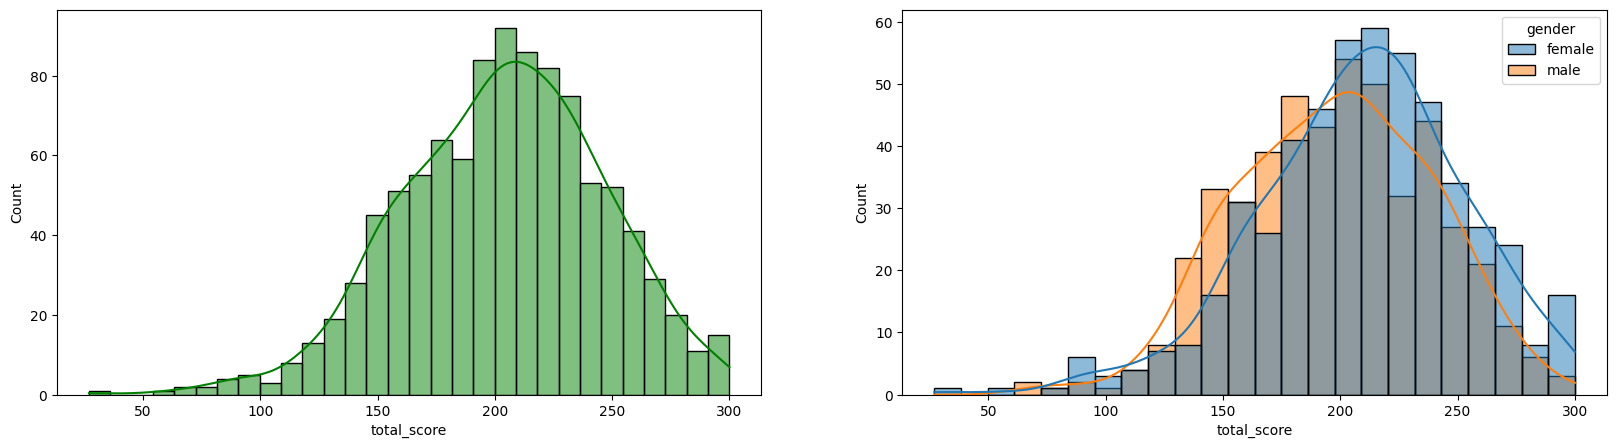

In [14]:
fig, axs = plt.subplots(1,3,figsize=(20,5))
plt.subplot(121)
sns.histplot(data = df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data = df,x='total_score',kde=True,hue='gender')
plt.show()

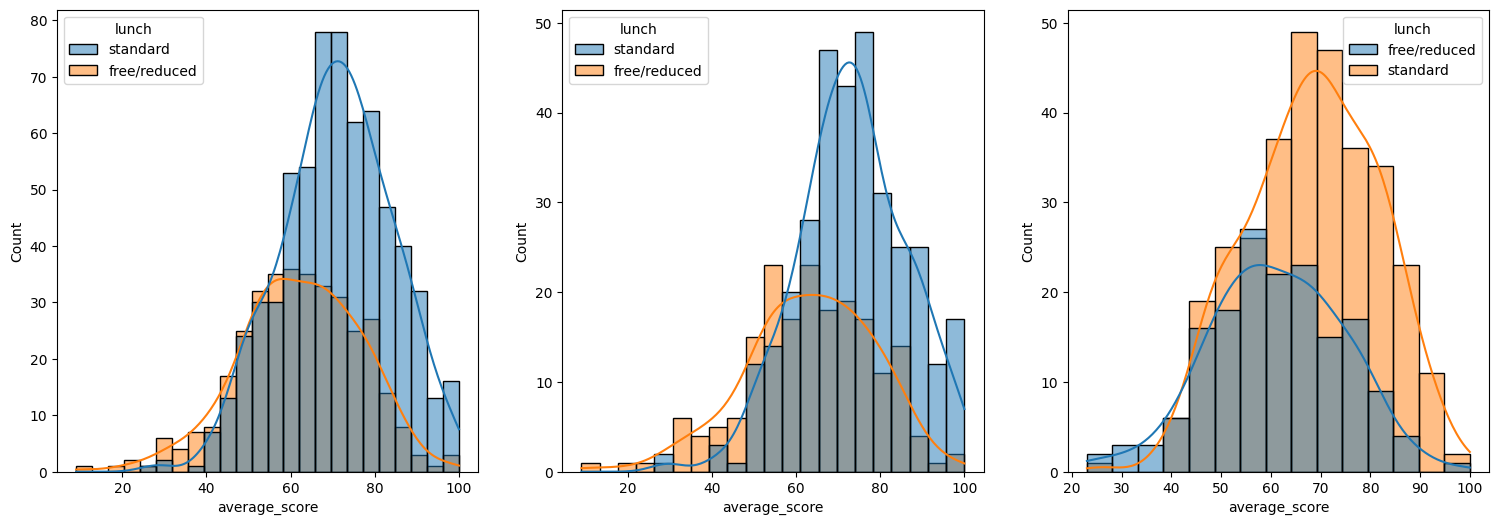

In [15]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data = df,x='average_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data = df[df.gender =='female'],x='average_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data = df[df.gender =='male'],x='average_score',kde=True,hue='lunch')
plt.show()

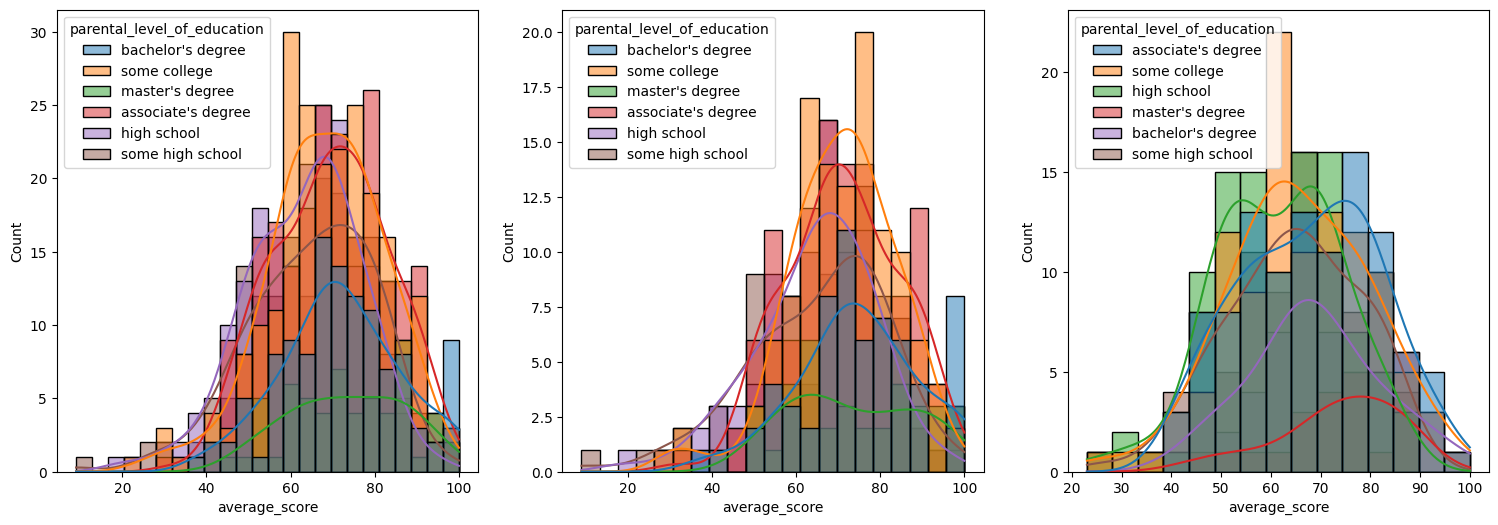

In [16]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data = df,x='average_score',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax = sns.histplot(data = df[df.gender =='female'],x='average_score',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax = sns.histplot(data = df[df.gender =='male'],x='average_score',kde=True,hue='parental_level_of_education')
plt.show()

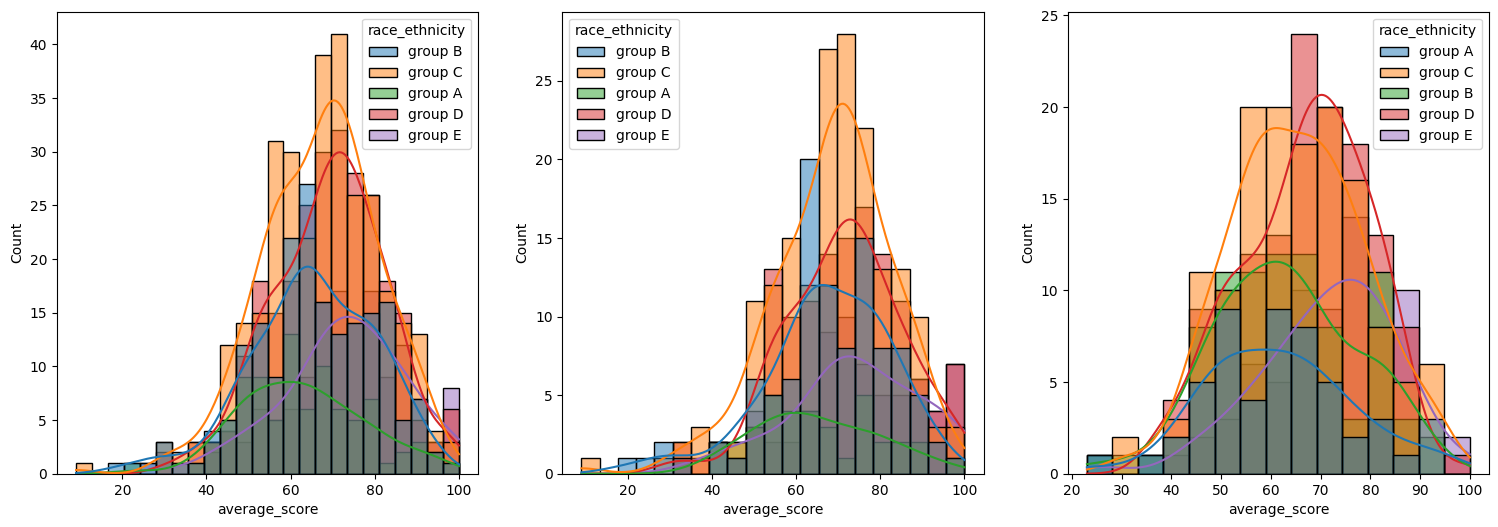

In [17]:
plt.subplots(figsize=(25,6))
plt.subplot(141)
ax = sns.histplot(data = df,x='average_score',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax = sns.histplot(data = df[df.gender=='female'],x='average_score',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax = sns.histplot(data = df[df.gender=='male'],x='average_score',kde=True,hue='race_ethnicity')
plt.show()

#### Maximum Scores of Students in all the 3 Subjects




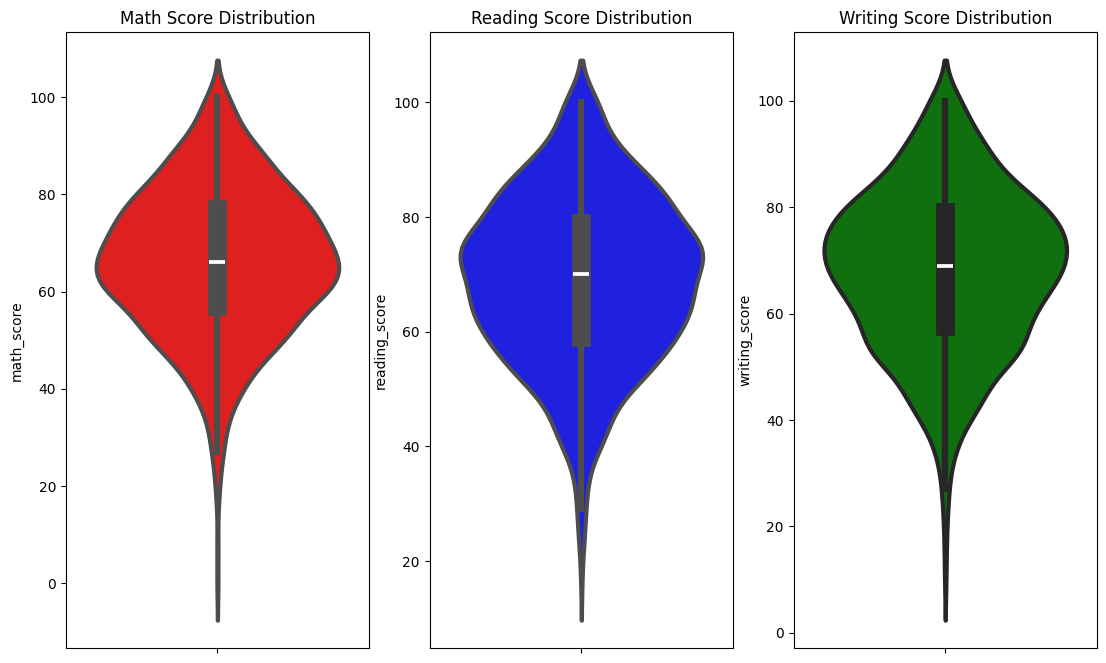

In [18]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Score Distribution')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Score Distribution')
sns.violinplot(y='reading_score',data=df,color='blue',linewidth=3)  
plt.subplot(1,4,3)
plt.title('Writing Score Distribution')
sns.violinplot(y='writing_score',data=df,color='green',linewidth=3)
plt.show()

#### Multivariate analysis using pieplot

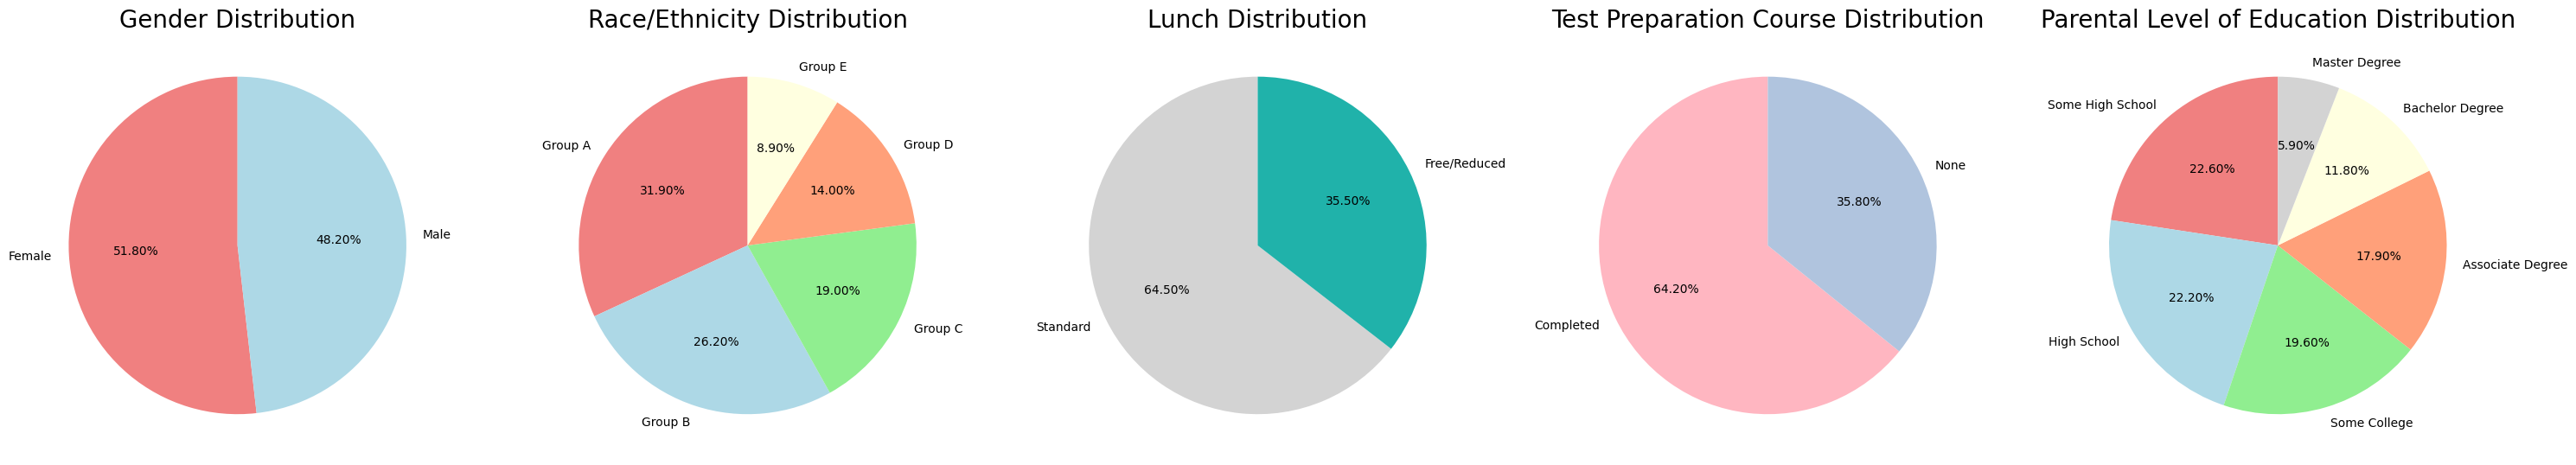

In [19]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['lightcoral','lightblue']

plt.pie(size,colors=color,labels=labels,autopct='%1.2f%%',startangle=90)
plt.title('Gender Distribution',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'Group A','Group B','Group C','Group D','Group E'
color = ['lightcoral','lightblue','lightgreen','lightsalmon','lightyellow']

plt.pie(size,colors=color,labels=labels,autopct='%1.2f%%',startangle=90)
plt.title('Race/Ethnicity Distribution',fontsize=20)
plt.axis('off')


plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard','Free/Reduced'
color = ['lightgray','lightseagreen']

plt.pie(size,colors=color,labels=labels,autopct='%1.2f%%',startangle=90)
plt.title('Lunch Distribution',fontsize=20)
plt.axis('off')


plt.subplot(1,5,4)
size = df['test_preparation_course'].value_counts()
labels = 'Completed','None'
color = ['lightpink','lightsteelblue']  

plt.pie(size,colors=color,labels=labels,autopct='%1.2f%%',startangle=90)
plt.title('Test Preparation Course Distribution',fontsize=20)
plt.axis('off')


plt.subplot(1,5,5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some High School','High School','Some College','Associate Degree','Bachelor Degree','Master Degree'
color = ['lightcoral','lightblue','lightgreen','lightsalmon','lightyellow','lightgray']

plt.pie(size,colors=color,labels=labels,autopct='%1.2f%%',startangle=90)
plt.title('Parental Level of Education Distribution',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

##### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )


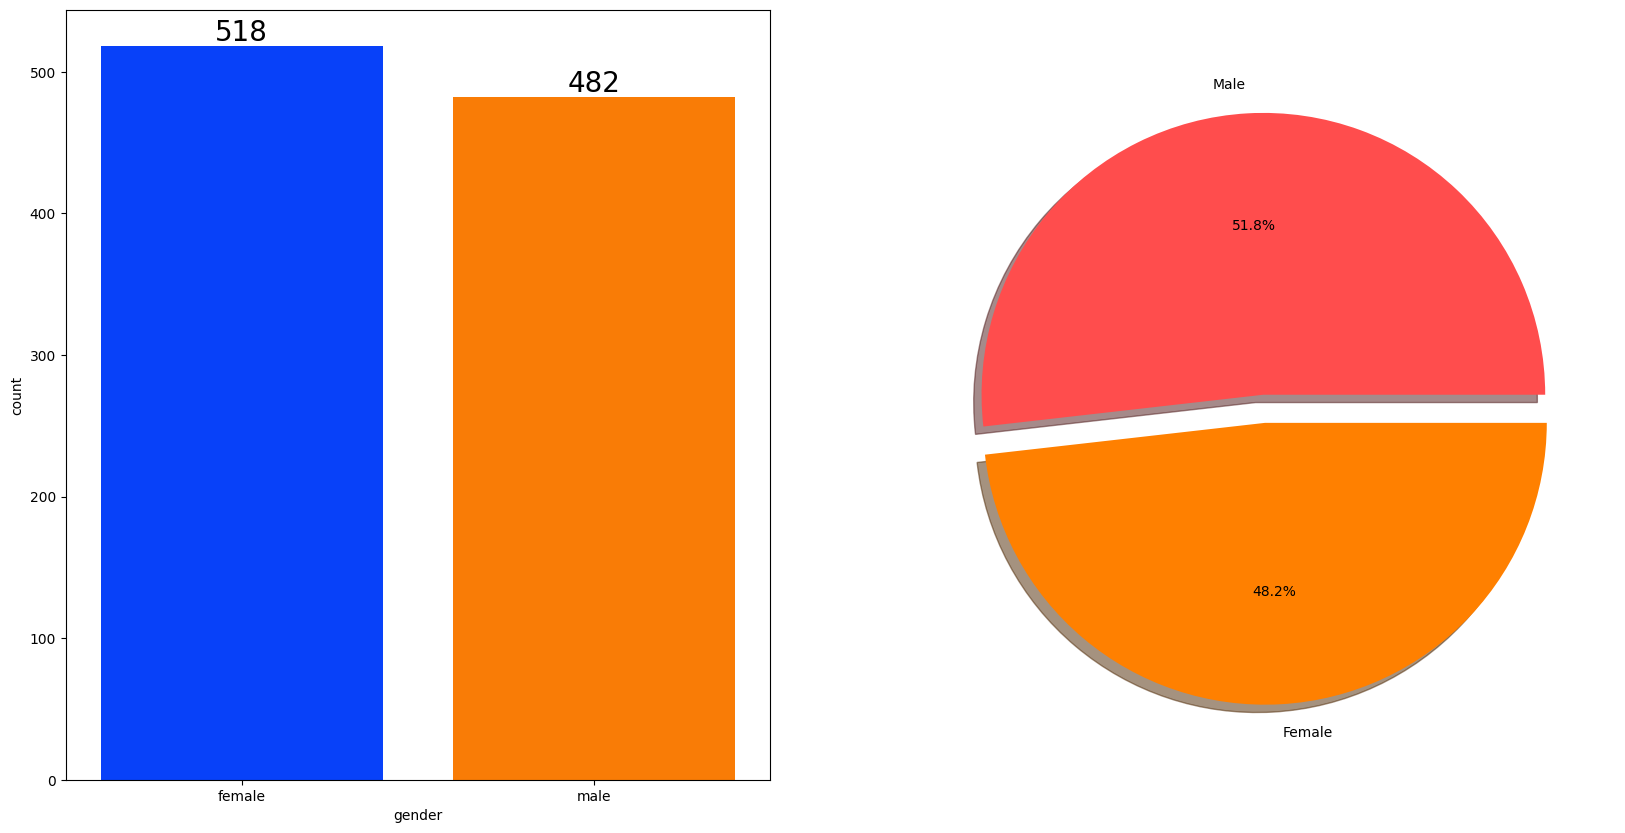

In [20]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

##### Insights

* Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

##### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [26]:
gender_group = df.groupby('gender')[['math_score', 'reading_score', 'writing_score','average_score','total_score']].mean()

gender_group

,math_score,reading_score,writing_score,average_score,total_score
gender,,,,,
female,63.633205,72.608108,72.467181,69.569498,208.708494
male,68.728216,65.473029,63.311203,65.837483,197.512448


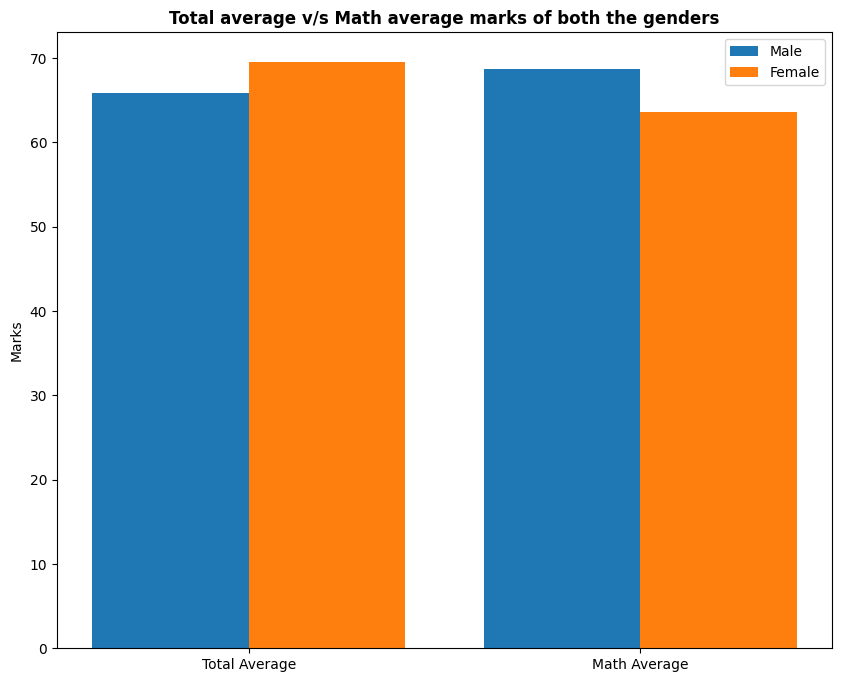

In [27]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average_score'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average_score'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

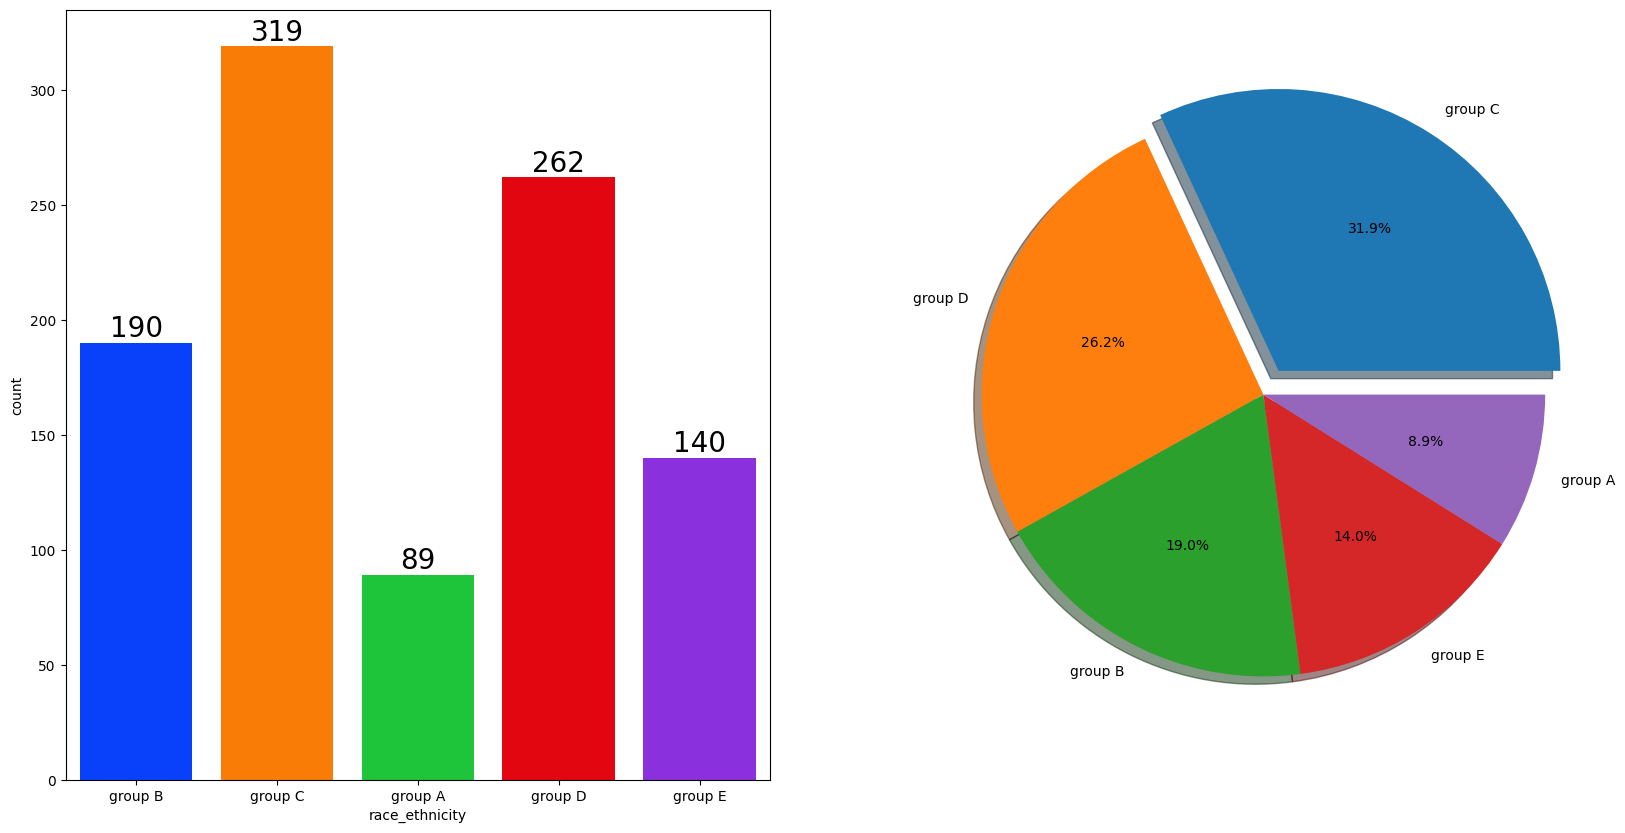

In [29]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights


* Most of the student belonging from group C /group D.
* Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

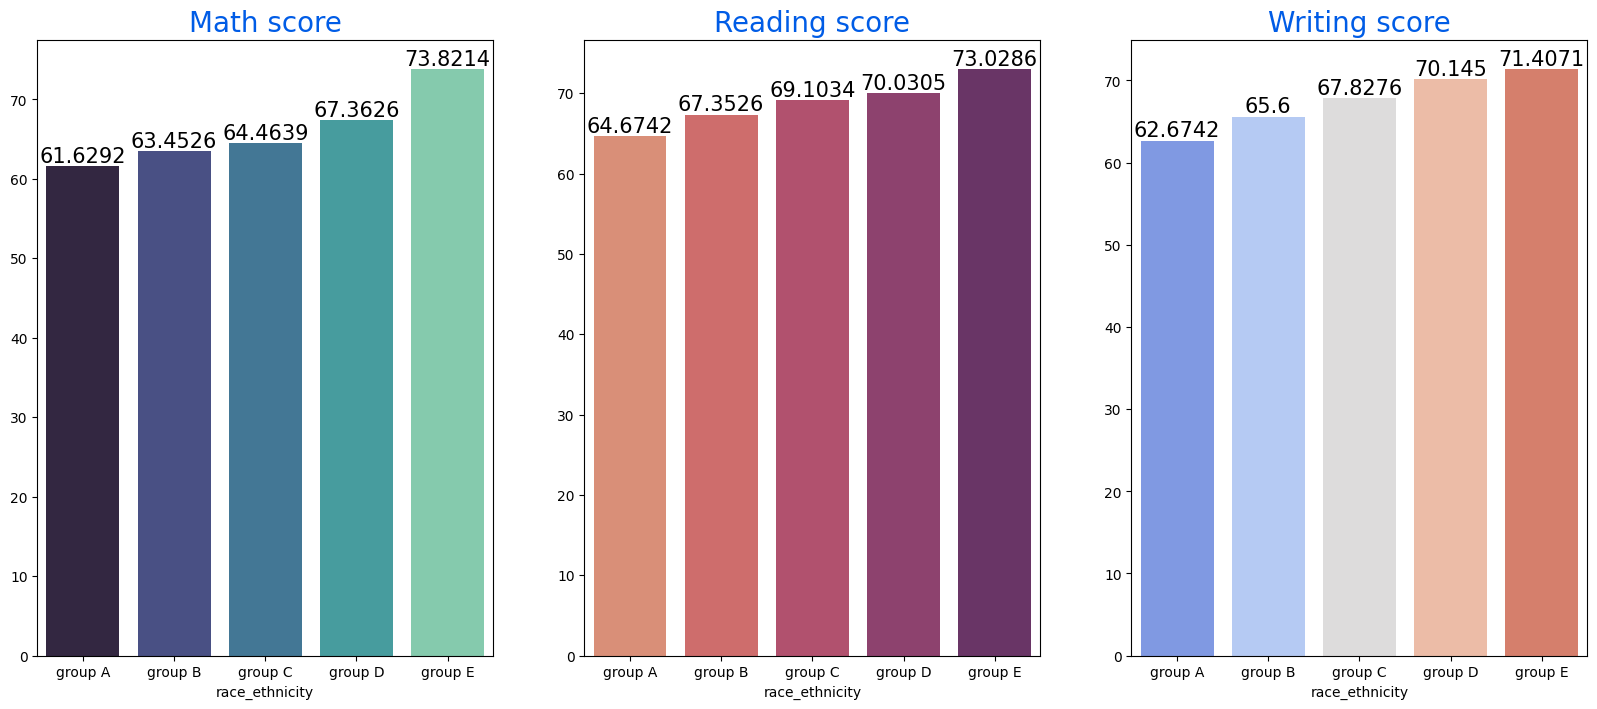

In [30]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights

* Group E students have scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN

* What is educational background of student's parent ?
* Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

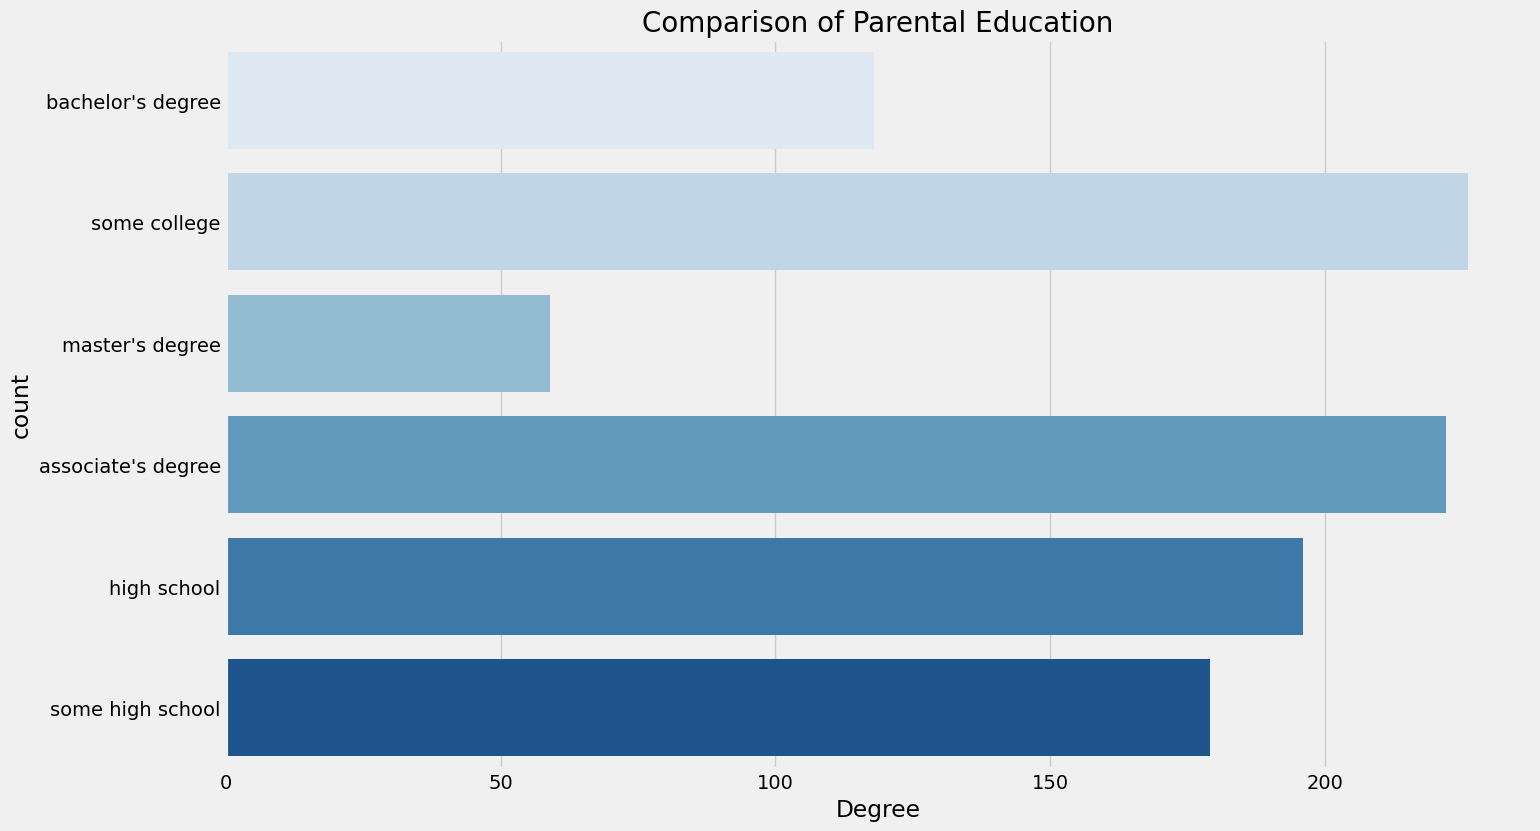

In [31]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

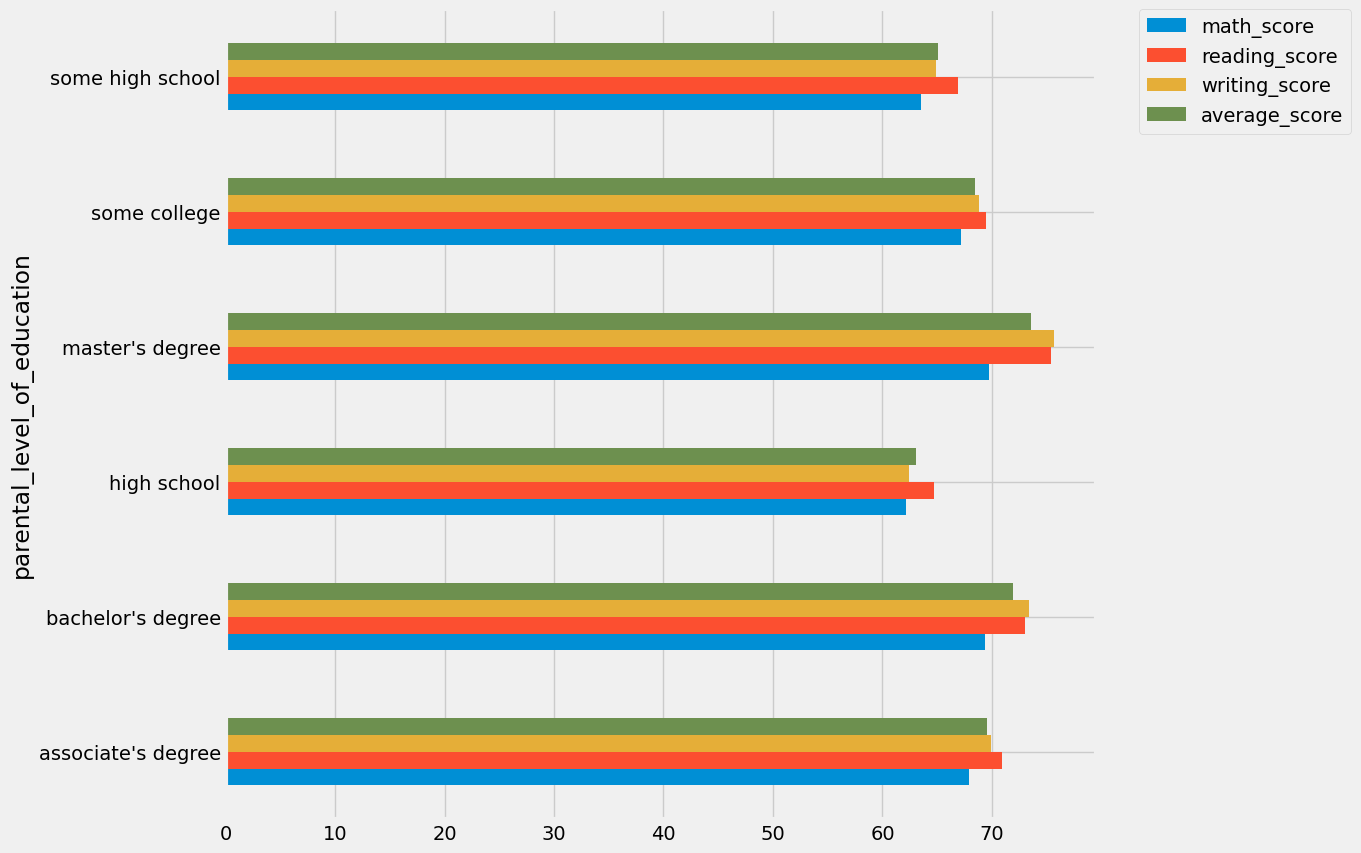

In [34]:
df.groupby('parental_level_of_education')[
    ['math_score', 'reading_score', 'writing_score', 'average_score']
].mean().plot(kind='barh', figsize=(10,10))

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

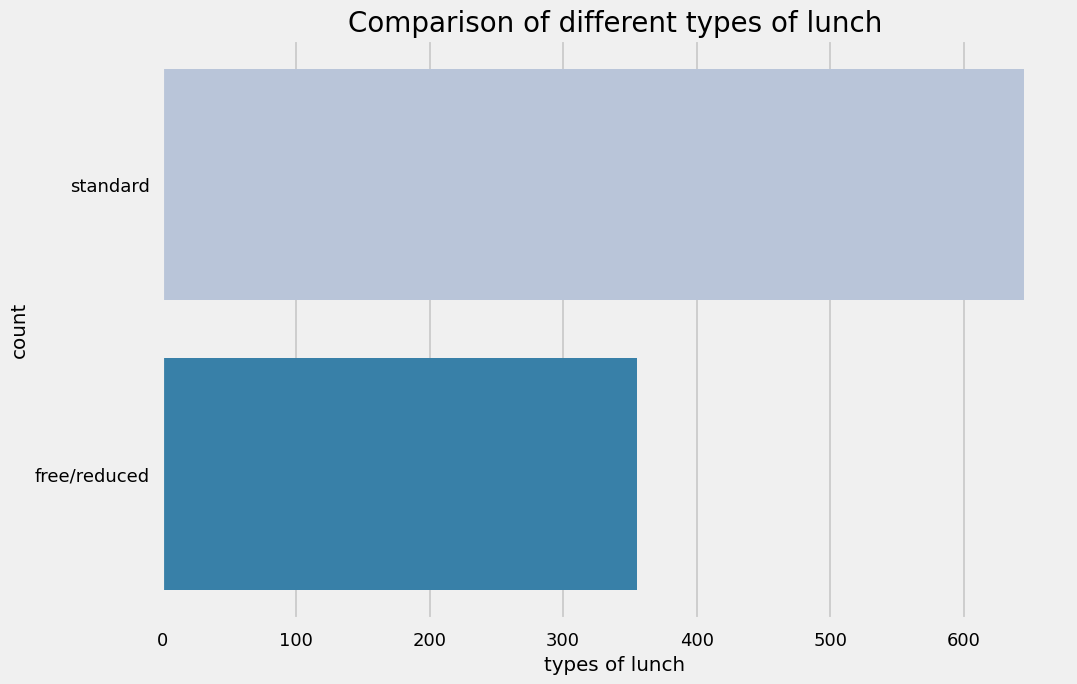

In [35]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

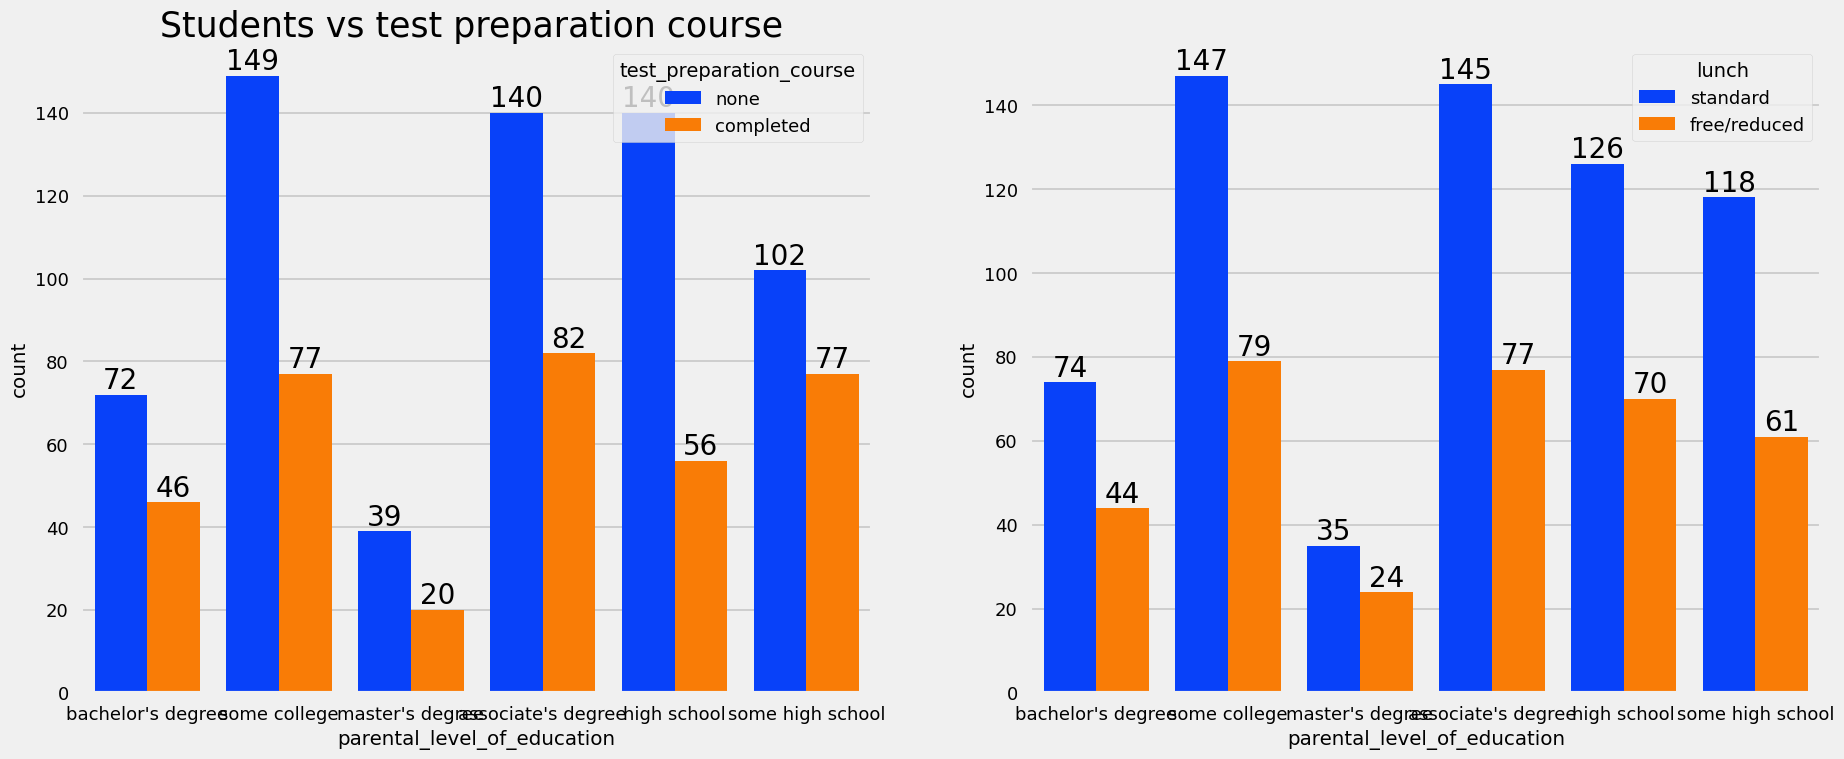

In [38]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

<Axes: xlabel='lunch', ylabel='writing_score'>

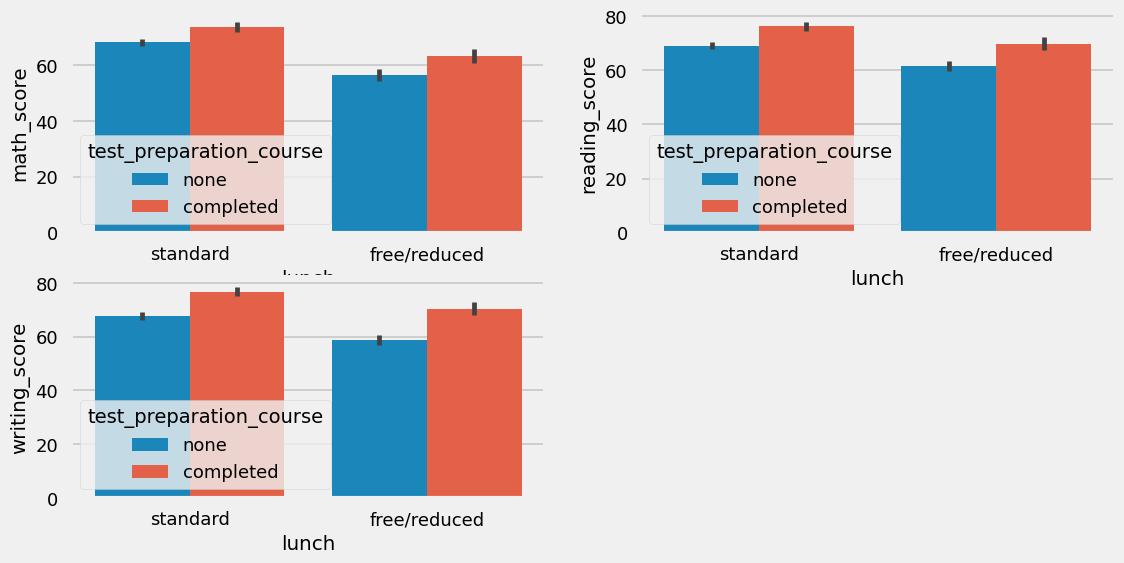

In [39]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

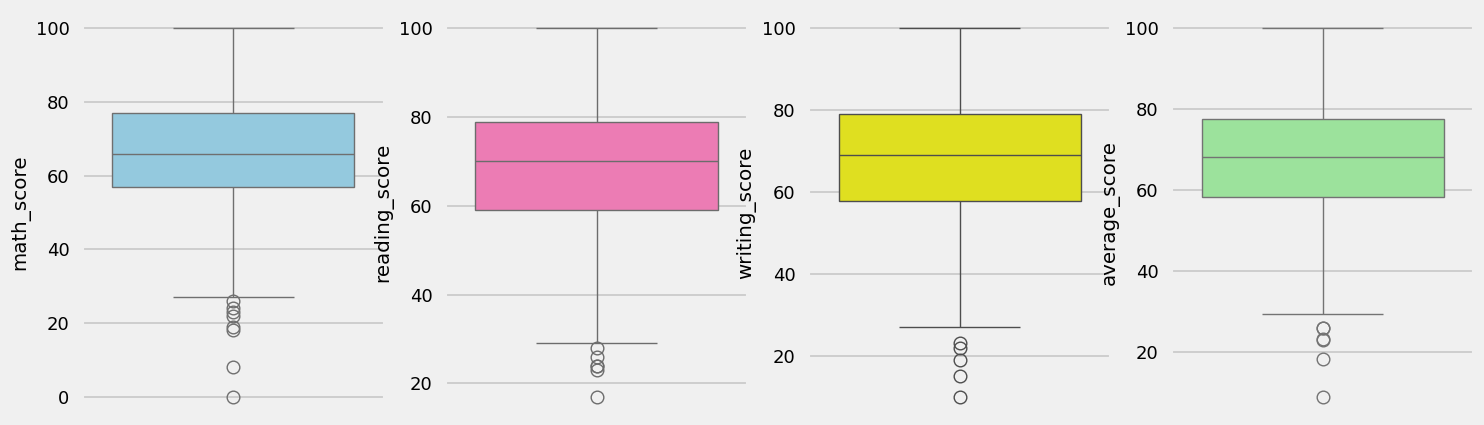

In [41]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

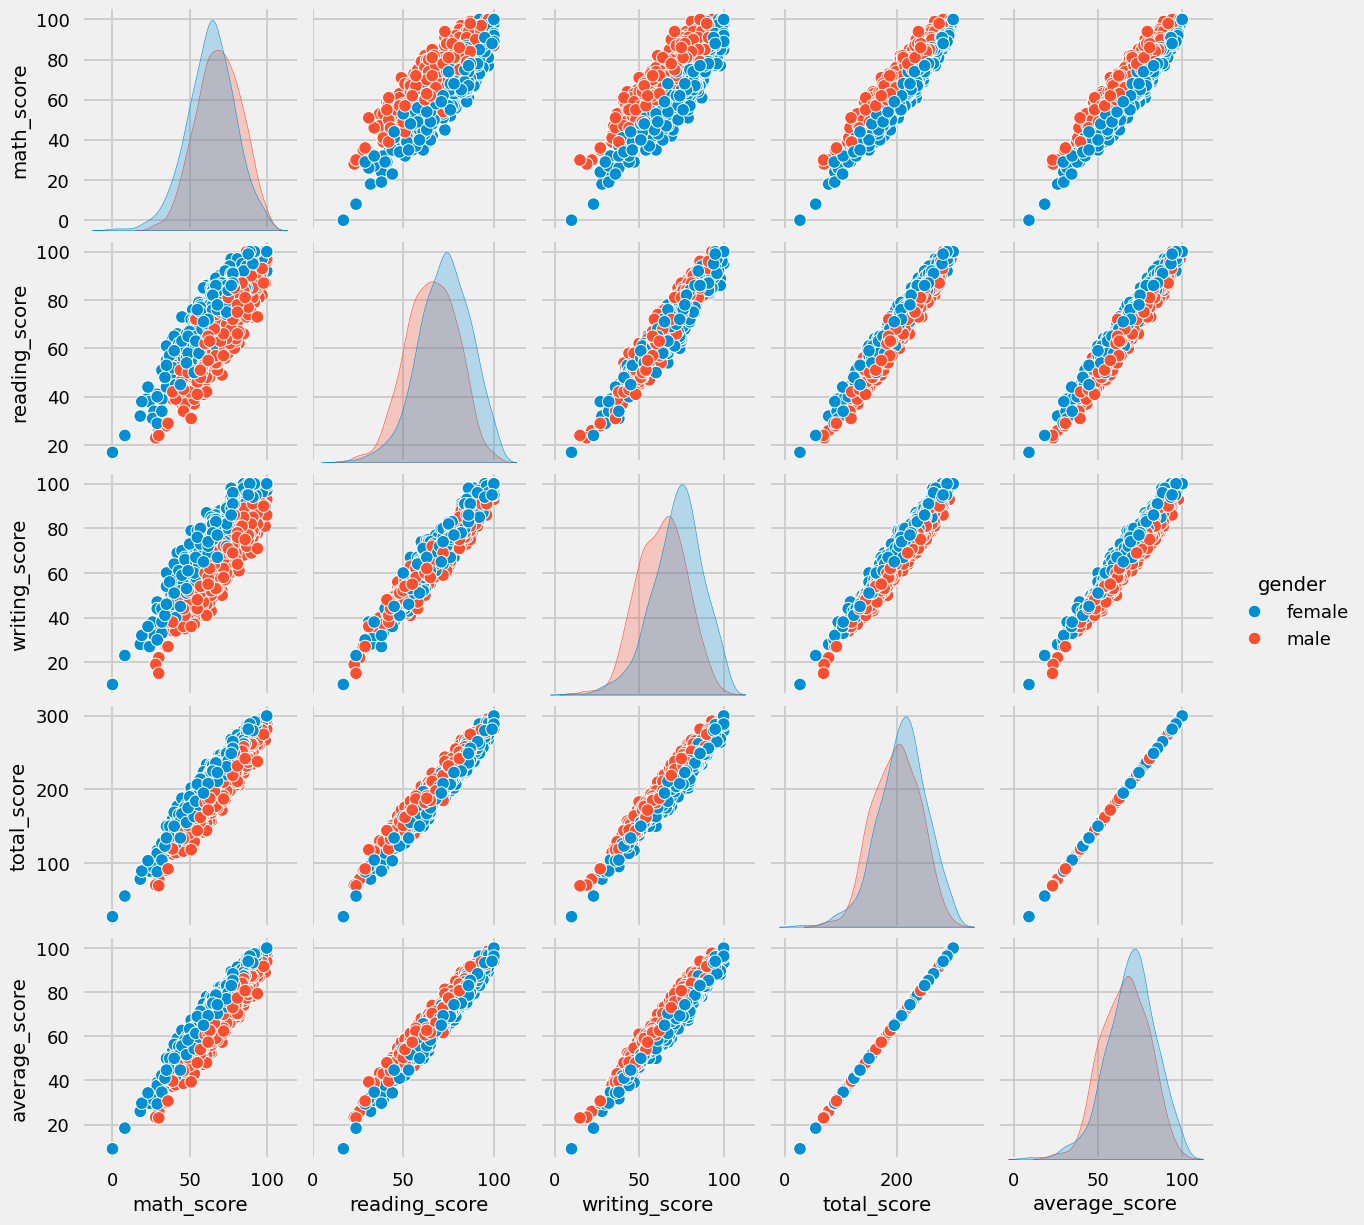

In [42]:
sns.pairplot(df,hue = 'gender')
plt.show()